[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_3b_SimilaritySearch.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# Bonus 3 — Similarity Search with Astromer2 Embeddings

In `Notebook_3_LightCurves` we found a strongly periodic variable (objectid `681116300004568`, period ≈ 28.7 d, likely Her X-1) in a 20-arcmin cone around RA = 254.5 deg, Dec = +35.3 deg.

Let's use represenation learning and similarity search to find the most similar light curve in the same cone.

We use the pre-trained Astromer2 ([Donoso-Oliva25+](https://arxiv.org/abs/2502.02717)) transformer model to turn each ZTF light curve into a 256-dimensional embedding, then find the nearest neighbour by cosine distance.
See the relevant `light-curve` package [documentation page](https://light-curve.snad.space/dev/embed/pre-executed/similarity_search/).

Pipeline:
1. **Non-lazy** — load the query object and compute its embedding directly.
2. **Lazy (LSDB)** — open the same cone and apply `map_rows` to embed every object; nothing executes until `.compute()`.
3. Find the nearest neighbour by cosine distance and plot both light curves.
4. What is this object?

In [1]:
# do you need to install the packages?
# if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb nested-pandas light-curve s3fs

In [2]:
import logging
import warnings

import dask
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np
import pandas as pd
import pyarrow as pa
from dask.distributed import Client
from light_curve.embed import Astromer2
from lsdb import ConeSearch
from matplotlib import rcParams
from scipy.spatial.distance import cdist

%matplotlib inline
warnings.simplefilter("ignore")
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 150
rcParams["font.size"] = 14
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 1.5
dask.config.set({"dataframe.convert-string": False})

In [3]:
client = Client(n_workers=1, memory_limit="10GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:52194/status


## Load the query object

We re-open ZTF DR24 in the same cone used in `Notebook_3_LightCurves` and pull out object `681116300004568` (filterid = 1).

In [4]:
ZTF_PATH = "s3://ipac-irsa-ztf/ztf/enhanced/dr24/lc/hats/"
cone = ConeSearch(ra=254.5, dec=35.3, radius_arcsec=20 * 60)
QUERY_OID = 681116300004568

ztf_query = lsdb.open_catalog(ZTF_PATH, search_filter=cone, filters=[("objectid", "==", QUERY_OID)])
ztf_query = ztf_query.query("lightcurve.catflags == 0")

query_df = ztf_query.compute()
query_row = query_df.iloc[0]
print(f"objectid={query_row['objectid']}, filterid={query_row['filterid']}, "
      f"n_epochs={len(query_row['lightcurve'])}")

objectid=681116300004568, filterid=1, n_epochs=1660


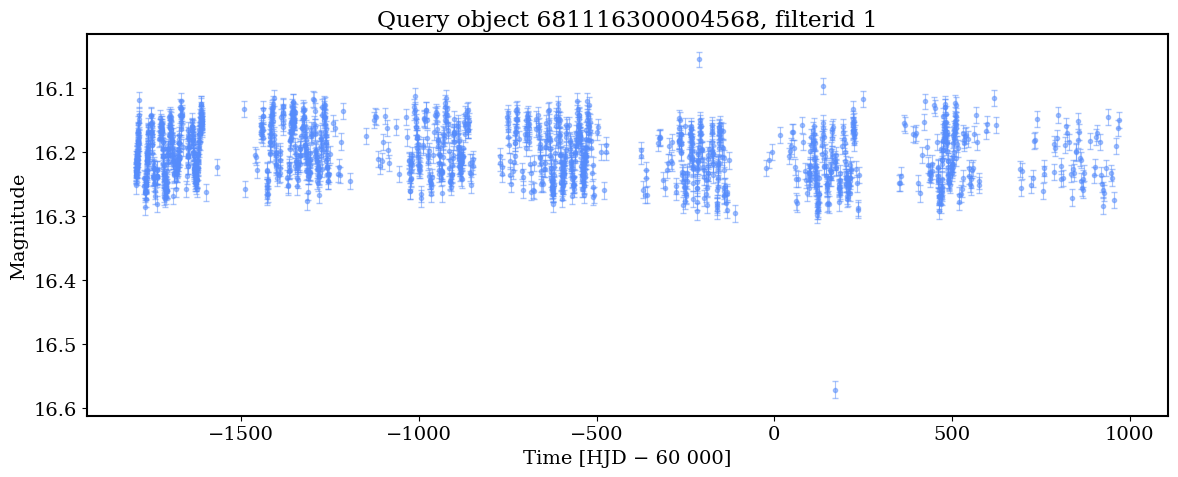

SNAD viewer: https://ztf.snad.space/view/681116300004568


In [5]:
lc = query_row["lightcurve"]
t = lc["hmjd"] - 60_000

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(t, lc["mag"], yerr=lc["magerr"],
            fmt="o", alpha=0.5, markersize=3, elinewidth=0.8, capsize=2)
ax.invert_yaxis()
ax.set_xlabel("Time [HJD − 60 000]")
ax.set_ylabel("Magnitude")
ax.set_title(f"Query object {query_row['objectid']}, filterid {query_row['filterid']}")
plt.tight_layout()
plt.show()
print(f"SNAD viewer: https://ztf.snad.space/view/{query_row['objectid']}")

## Compute the query embedding (non-lazy)

We load Astromer2 in the main process and embed the query light curve directly — no Dask involved.

In [6]:
# Downloads once from HuggingFace Hub, then cached to disk
embed_model = Astromer2.from_hf()

query_embedding = embed_model(lc["hmjd"], lc["mag"]).squeeze()
print(f"Embedding shape: {query_embedding.shape}")

Embedding shape: (256,)


## Lazily embed the full cone with LSDB

`map_partitions` loads the model once per partition. Dask dry-runs the function on an empty partition slice to infer the output schema, so we guard against that: when `len(partition) == 0` we skip `Astromer2.from_hf` entirely and let `map_rows` derive the schema from `meta=` without ever calling the row function.

In [7]:
def _embed_partition(partition):
    # Skip model load on empty partitions (Dask meta-derivation pass)
    if len(partition) == 0:
        return partition.assign(embedding=pd.Series([], dtype=npd.NestedDtype({"value": pa.float32()})))

    model = Astromer2.from_hf()

    return partition.map_rows(
        lambda hmjd, mag: {"embedding.value": model(hmjd, mag).squeeze()},
        columns=["lightcurve.hmjd", "lightcurve.mag"],
        row_container="args",
        append_columns=True,
    )

ztf_sim = lsdb.open_catalog(
    ZTF_PATH,
    search_filter=cone,
    columns=["objectid", "filterid", "lightcurve.hmjd", "lightcurve.mag", "lightcurve.catflags"],
)
ztf_sim = ztf_sim.query("lightcurve.catflags == 0")
ztf_sim = ztf_sim.query("lightcurve.len() >= 1000")
ztf_sim = ztf_sim.map_partitions(_embed_partition)
ztf_sim

,objectid,filterid,objra,objdec,lightcurve,embedding
npartitions=1,,,,,,
"Order: 5, Pixel: 2378",int64[pyarrow],int8[pyarrow],float[pyarrow],float[pyarrow],"nested<hmjd: [double], mag: [float], catflags:...",nested<value: [float]>


## Compute and find the nearest neighbour

In [8]:
%%time
df_sim = ztf_sim.compute()
df_sim

2026-06-15 07:21:44,910 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.02 GiB -- Worker memory limit: 10.00 GiB
/Users/hombit/.virtualenvs/lsdb-release/lib/python3.13/site-packages/light_curve/embed/model.py:60: ExperimentalWarning: light_curve.embed.astromer.Astromer2 is experimental and may change in future versions
  warn_experimental(


CPU times: user 6.87 s, sys: 2.75 s, total: 9.62 s
Wall time: 7min 17s


objectid  filterid       objra     objdec  \
_healpix_29                                                            
669511326540316851  680213300014409         2  254.450729  35.602398   
669511331887988572  680213300006138         2  254.442459  35.604893   
...                             ...       ...         ...        ...   
669406716430715207  681116300005002         1  254.813568  35.370426   
669406716430729092  680213400008879         2  254.813568  35.370441   

                                                           lightcurve  \
_healpix_29                                                             
669511326540316851  [{hmjd: 58198.39511, mag: 20.14003, catflags: ...   
669511331887988572  [{hmjd: 58198.39511, mag: 20.358227, catflags:...   
...                                                               ...   
669406716430715207  [{hmjd: 58203.40142, mag: 17.37554, catflags: ...   
669406716430729092  [{hmjd: 58198.39508, mag: 16.339703, catflags:...   

                                             embedding  
_healpix_29                                             
669511326540316851  [{value: -0.536801}; …] (256 rows)  
669511331887988572  [{value: -0.544882}; …] (256 rows)  
...                                                ...  
669406716430715207  [{value: -0.538402}; …] (256 rows)  
669406716430729092  [{value: -0.538271}; …] (256 rows)  

[3705 rows x 6 columns]

In [16]:
client.close()

In [9]:
# Stack embeddings into an (N, 256) matrix
embedding_matrix = np.asarray(df_sim["embedding.value"]).reshape(len(df_sim), -1)

# Cosine distance from the query to every object
distances = cdist(query_embedding.reshape(1, -1), embedding_matrix, metric="cosine")[0]

# Mask out the query object itself
is_query = df_sim["objectid"] == QUERY_OID
distances[is_query] = np.inf

nn_idx = np.argmin(distances)
nn_row = df_sim.iloc[nn_idx]
print(f"Nearest neighbour: objectid={nn_row['objectid']}, filterid={nn_row['filterid']}")
print(f"Cosine distance: {distances[nn_idx]:.6f}")
print(f"SNAD viewer: https://ztf.snad.space/view/{nn_row['objectid']}")

Nearest neighbour: objectid=681216300009149, filterid=2
Cosine distance: 0.000001
SNAD viewer: https://ztf.snad.space/view/681216300009149


## Compare the two light curves

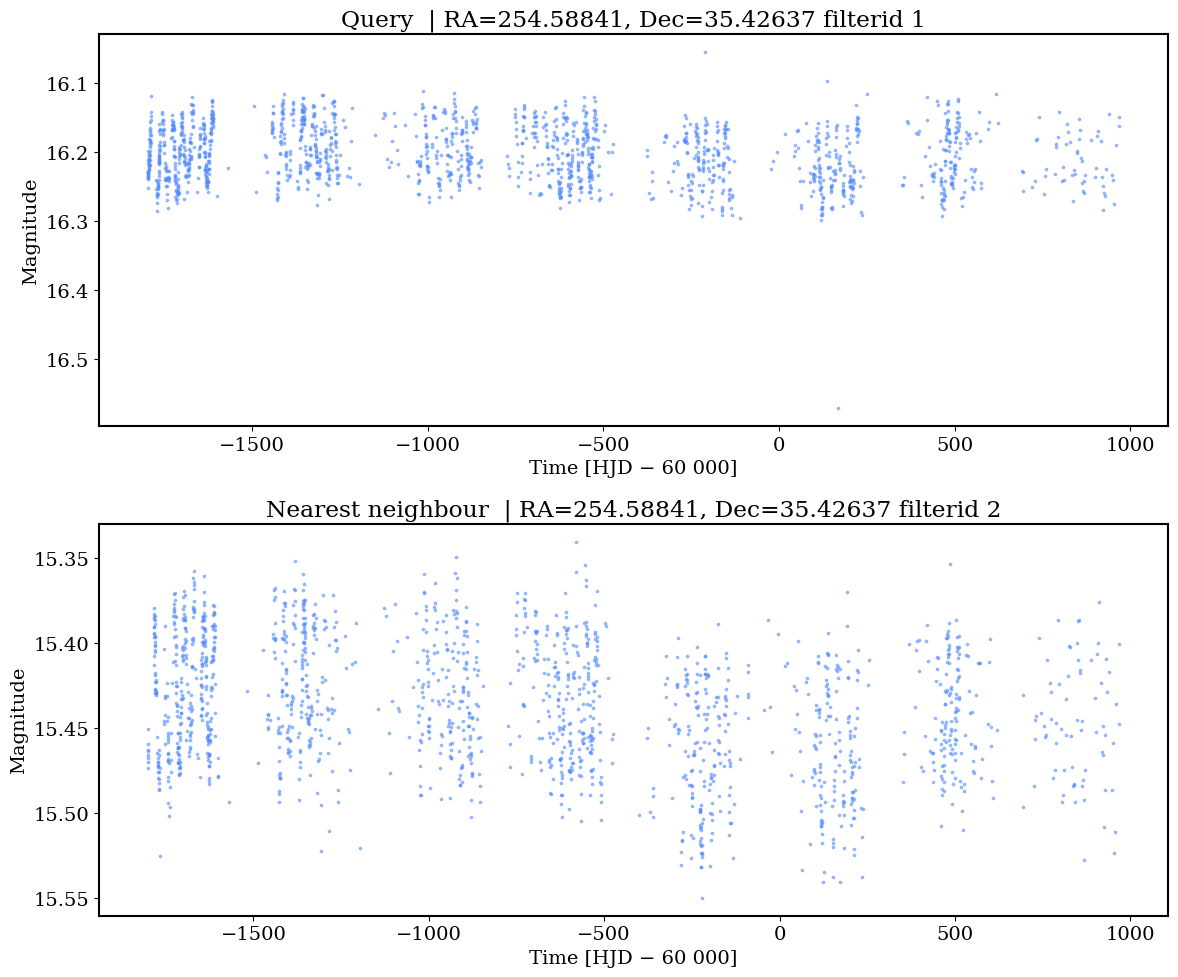

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for ax, r, label in zip(
    axes,
    [query_row, nn_row],
    ["Query", "Nearest neighbour"],
):
    lc = r["lightcurve"]
    t = lc["hmjd"] - 60_000
    ax.scatter(t, lc["mag"], marker="o", alpha=0.5, s=3)
    ax.invert_yaxis()
    ax.set_xlabel("Time [HJD − 60 000]")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{label}  | RA={r['objra']:.5f}, Dec={r['objdec']:.5f} filterid {r['filterid']}")

plt.tight_layout()
plt.show()

We have found the same variable star, but in a different filter (filterid 1 is g-band, filterid 2 is r-band)!